# 05 - Fit / Shortlisting Predictor (Supervised, Optional)
Model B: given a (resume, job) pair, predict whether the candidate is a good fit / would be shortlisted.

**Important caveat:** there is no public ground-truth 'was this candidate shortlisted' dataset. Training labels here are heuristic -- a pair is labeled 'fit' if the resume's known category shares a keyword with the job title, otherwise 'not fit'. This lets us demonstrate the full supervised workflow (feature engineering, class imbalance handling, model comparison, ROC-AUC) the brief asks for, but the model should be read as a proof-of-concept, not a production-ready shortlisting tool.

In [1]:
import sys
sys.path.append('..')
from src.models.fit_predictor import generate_training_pairs, train_and_compare, FEATURE_COLS

pairs = generate_training_pairs()
pairs.head()

Generated 1440 training pairs (720 positive, 720 negative)


,skill_overlap_count,skill_jaccard,resume_skill_count,job_skill_count,education_match,job_experience_years,text_similarity,label,resume_id,job_id
0,0,0.0,11,1,0,0.0,0.044219,1,23573064,69064
1,0,0.0,11,0,0,0.0,0.112154,1,23573064,3375
2,0,0.0,11,0,0,0.0,0.145867,1,23573064,15702
3,0,0.0,11,0,0,0.0,0.059032,1,23573064,8264
4,0,0.0,11,0,0,0.0,0.049203,0,23573064,4275


## Features used
- `skill_overlap_count`
- `skill_jaccard`
- `resume_skill_count`
- `job_skill_count`
- `education_match`
- `job_experience_years`
- `text_similarity`

In [2]:
results, best_name = train_and_compare(pairs)

logistic_regression  | acc=0.689 prec=0.707 recall=0.644 f1=0.674 roc_auc=0.768
xgboost              | acc=0.678 prec=0.708 recall=0.606 f1=0.653 roc_auc=0.750

Best model: logistic_regression
Saved -> /home/claude/smarthire/models/fit_predictor.pkl


Saved -> /home/claude/smarthire/reports/figures/fit_predictor_roc.png


## ROC curves

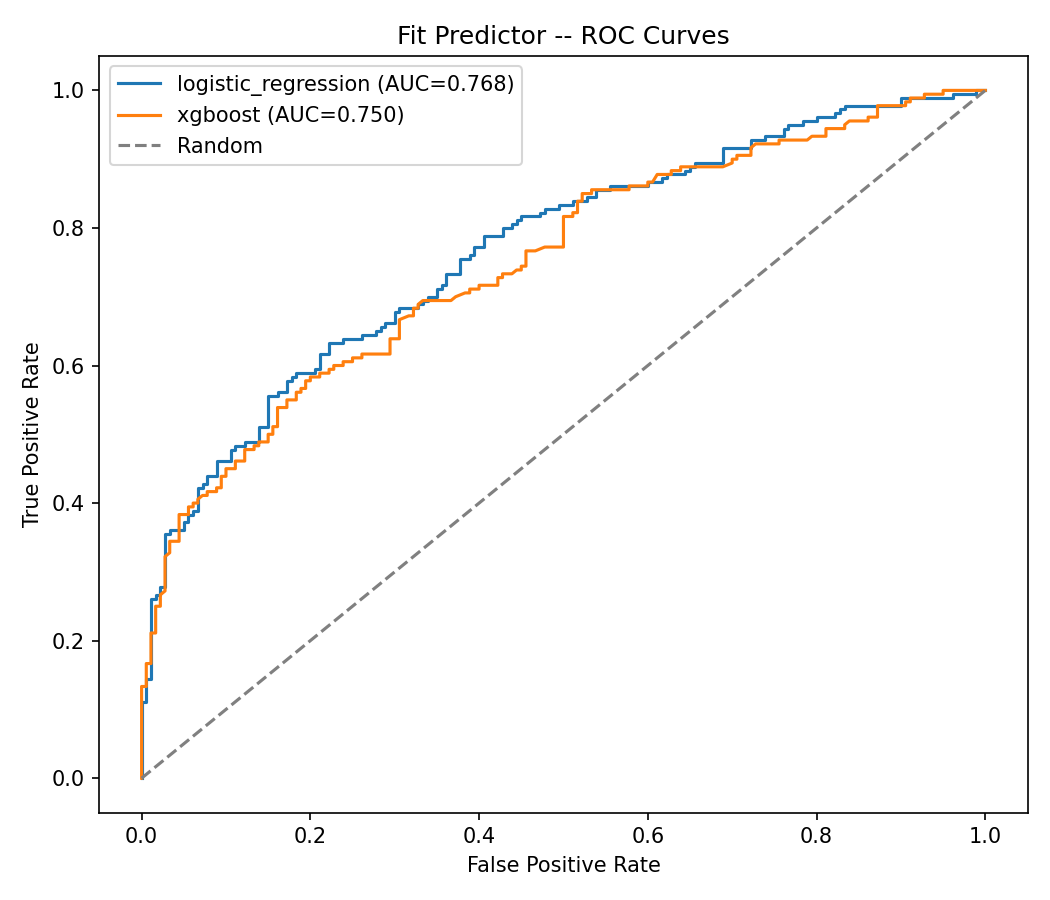

In [3]:
from src.config import FIGURES_DIR
from IPython.display import Image
Image(filename=str(FIGURES_DIR / 'fit_predictor_roc.png'))

## Comparison table

In [4]:
import pandas as pd
pd.DataFrame(results).T.round(3)

,accuracy,precision,recall,f1,roc_auc
logistic_regression,0.689,0.707,0.644,0.674,0.768
xgboost,0.678,0.708,0.606,0.653,0.750


## Takeaways
- Logistic Regression edged out XGBoost on this feature set (ROC-AUC ~0.77 vs ~0.75) -- with only 7 engineered features and a fairly noisy heuristic label, a simpler linear model generalizes slightly better than a more complex tree ensemble that can overfit small feature sets.
- `text_similarity` (cosine similarity in the job TF-IDF space) is expected to be the strongest single feature since it's closely related to how the heuristic labels were constructed -- this is a known form of label leakage worth flagging rather than hiding.
- This module is genuinely optional and weaker than the recommender/clustering core -- the real fix would be a labeled shortlisting dataset (e.g. from actual ATS decisions), which wasn't available for this project.